In [1]:
import os
import requests
from PIL import Image
from tqdm import tqdm
from torch.utils.data import Dataset
from transformers import AutoTokenizer
from datasets import load_dataset
import transformers
from peft import get_peft_model, PrefixTuningConfig, TaskType
from transformers import Trainer, TrainingArguments
import torch
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
import re
from qwen_vl_utils import process_vision_info

In [2]:
import json
from PIL import Image


# 假设你的 JSON 文件名为 data.json
with open("/root/IC_MLLM_VQA/Score/train_with_score_1_6.json", "r", encoding="utf-8") as f:
    dataset_train = json.load(f)

In [3]:
with open("/root/IC_MLLM_VQA/Score/val_with_score_1_6.json", "r", encoding="utf-8") as f:
    dataset_val = json.load(f)

Question: Select the amphibian below.
Choices: ['common toad', 'rabbit']
Hint: Amphibians have moist skin and begin their lives in water. A barking tree frog is an example of an amphibian.
Grade: grade3
Answer: 0
Explanation: The solution and lecture are :A common toad is an amphibian. It has moist skin and begins its life in water.
Toads do not have teeth! They swallow their food whole.
A rabbit is a mammal. It has fur and feeds its young milk.
Rabbits live underground in burrows. A group of rabbit burrows is called a warren.

Birds, mammals, fish, reptiles, and amphibians are groups of animals. The animals in each group have traits in common.
Scientists sort animals into groups based on traits they have in common. This process is called classification.
score: **[Your Score]: 0.8**
Image type: <class 'str'>
Image path: /root/IC_MLLM_VQA/Score/train_filtered_images1-6/img_5799.jpg


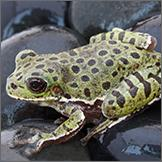

In [4]:
from random import choice

sample_1 = choice(dataset_train)
print(f"Question: {sample_1['question']}")
print(f"Choices: {sample_1['choices']}")
print(f"Hint: {sample_1['hint']}")
print(f"Grade: {sample_1['grade']}")
print(f"Answer: {sample_1['answer']}")
print(f"Explanation: {sample_1['solution_lecture']}")
print(f'score: {sample_1["model_score"]}')
print(f"Image type: {type(sample_1['image'])}")
image_path = '/root/IC_MLLM_VQA/Score/' + sample_1['image']
print(f"Image path: {image_path}")
img = Image.open(image_path)
img.show()


In [5]:
from torch.utils.data import Dataset
from PIL import Image
import torch

class QwenVLPrefixDataset(Dataset):
    def __init__(self, data_list, processor, debug=False):
        self.data_list = data_list
        self.processor = processor
        self.debug = debug

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        sample = self.data_list[idx]
        return self.build_training_sample(sample)

    def build_training_sample(self, sample):
        # 1. 构造答案
        if isinstance(sample["answer"], int):
            answer_index = sample["answer"]
        else:
            answer_index = sample["choices"].index(sample["answer"])
        answer_letter = chr(65 + answer_index)

        # 2. 构建问题内容
        question_text = f"Question: {sample['question']}\nChoices:\n"
        for idx, choice in enumerate(sample["choices"]):
            question_text += f"{chr(65 + idx)}. {choice}\n"
        if sample.get("hint"):
            question_text += f"\nHint: {sample['hint']}\n"
        question_text += (
            "\nHere is a image:\n"
            "Please select the correct answer. Then, explain your reasoning in detail and in English. "
            "Make sure your explanation is at least three sentences long, "
            "refers to specific data from the image, and shows your step-by-step logic."
        )

        # 3. 构建 label 文本（拼接到 prompt 后）
        label_text = f"\nAnswer: {answer_letter}\nExplanation: {sample['solution_lecture']}"

        # 4. 图像处理
        image_path = os.path.join("/root/IC_MLLM_VQA/Score", sample["image"])  # 用 join 更安全
        image = Image.open(image_path)  # 这里才是 PIL.Image.Image 类型
        image = image.convert("RGB").resize((224, 224))

        # 5. 构造完整对话 + 图像输入
        chat = [
            {"role": "user", "content": [
                {"type": "text", "text": question_text},
                {"type": "image", "image": image}
            ]},
            {"role": "assistant", "content": label_text}
        ]

        # 6. 编码图文输入（注意：一体编码 prompt+label）
        text = self.processor.apply_chat_template(chat, tokenize=False, add_generation_prompt=False)
        image_inputs, video_inputs = process_vision_info(chat)
        
        inputs = self.processor(
            text=text,
            images=image_inputs,
            return_tensors="pt",
            padding=False,
            truncation=False
        )

        # 7. 构造 labels —— 用 input_ids 克隆，并 mask 掉前面的 prompt
        input_ids = inputs["input_ids"].squeeze(0)
        attention_mask = inputs["attention_mask"].squeeze(0)

        # 找到 label 的起始位置：用 processor 再只 encode user 部分计算长度
        user_text_only = self.processor.apply_chat_template(chat[:1], tokenize=False, add_generation_prompt=False)
        user_input_ids = self.processor.tokenizer(user_text_only, return_tensors="pt", add_special_tokens=False)["input_ids"][0]
        user_len = user_input_ids.shape[-1]

        labels = input_ids.clone()
        labels[:user_len] = -100  # mask prompt 部分
        
        score_str = sample.get('model_score', '0.0')  # 从原字段中取出字符串
        match = re.search(r"[\d.]+", score_str)
        score = float(match.group()) if match else 0.0

        result = {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
            "pixel_values": inputs["pixel_values"].squeeze(0),
            'score': score # 添加分数字段
        }

        if "image_grid_thw" in inputs:
            result["image_grid_thw"] = inputs["image_grid_thw"].squeeze(0)

        if self.debug:
            print(f"[DEBUG] input_ids.shape: {input_ids.shape}")
            print(f"[DEBUG] labels.shape: {labels.shape}")

        return result


In [6]:
processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-7B-Instruct")
train_dataset_score = QwenVLPrefixDataset(dataset_train, processor, debug=False)
val_dataset_score = QwenVLPrefixDataset(dataset_val, processor, debug=False)
print(f"Dataset train length: {len(train_dataset_score)}")
print(f"Dataset val length: {len(val_dataset_score)}")

# 检查数据集中的第一个样本
# sample = train_dataset_score[0]
# print(sample)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Dataset train length: 4349
Dataset val length: 1481


In [7]:
from transformers import AutoProcessor
from torch.utils.data import DataLoader

processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-7B-Instruct")
train_dataset = QwenVLPrefixDataset(dataset_train, processor, debug=False)
dataloader = DataLoader(train_dataset, batch_size=6, shuffle=True)

In [8]:
import torch
from torch.nn.utils.rnn import pad_sequence

def qwen_vl_collate_fn(batch):
    """
    Collate 函数，用于 QwenVL 多模态模型训练。
    自动对 input_ids / labels 进行 padding，
    pixel_values 和 image_grid_thw 直接 stack（假设 shape 一致）。
    """
    def pad_tensor_list(tensor_list, pad_value=0):
        return pad_sequence(tensor_list, batch_first=True, padding_value=pad_value)

    input_ids = [item["input_ids"] for item in batch]
    attention_mask = [item["attention_mask"] for item in batch]
    labels = [item["labels"] for item in batch]
    score = [item["score"] for item in batch]  # 添加分数字段

    # 部分模型 forward 需要 attention_mask，尽管有些模型不强依赖，也建议保留
    input_ids = pad_tensor_list(input_ids, pad_value=0)
    attention_mask = pad_tensor_list(attention_mask, pad_value=0)
    labels = pad_tensor_list(labels, pad_value=-100)  # 避免 loss 对 pad token 计算

    # 多模态部分
    pixel_values = torch.stack([item["pixel_values"] for item in batch])
    
    # 可选：容错处理 image_grid_thw（有些模型可能没有）
    if "image_grid_thw" in batch[0]:
        image_grid_thw = torch.stack([item["image_grid_thw"] for item in batch])
    else:
        image_grid_thw = None

    # 构造返回字典
    result = {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
        "pixel_values": pixel_values,
        'score':torch.tensor(score, dtype=torch.float32)
        
    }
    # print(f"input_ids shape: {input_ids.shape}, attention_mask shape: {attention_mask.shape}, labels shape: {labels.shape}, pixel_values shape: {pixel_values.shape}")
    if image_grid_thw is not None:
        result["image_grid_thw"] = image_grid_thw

    return result


In [9]:
from torch.utils.data import DataLoader

# 正确使用 collate_fn
dataloader = DataLoader(train_dataset_score, batch_size=1, shuffle=False, collate_fn=qwen_vl_collate_fn)

# 获取第一个 batch
first_batch = next(iter(dataloader))

# 查看第一个样本的结构
n = 0
print("==== 第一个 batch 的第一个样本 ====")
print(f"input_ids shape: {first_batch['input_ids'][n].shape}")
print(f"attention_mask shape: {first_batch['attention_mask'][0].shape}")
print(f"labels shape: {first_batch['labels'][n].shape}")
print(f"pixel_values shape: {first_batch['pixel_values'][n].shape}")
print(f"image_grid_thw shape: {first_batch['image_grid_thw'][n].shape}")
print(f"score: {first_batch['score'][n]}")

# 可选：查看文本内容（需要 tokenizer）
tokenizer = processor.tokenizer
decoded_input = tokenizer.decode(first_batch['input_ids'][n], skip_special_tokens=True)
decoded_label = tokenizer.decode(
    [id for id in first_batch['labels'][n].tolist() if id != -100],
    skip_special_tokens=True
)

print("\n--- 解码后的 input_ids ---")
print(decoded_input)

print("\n--- 解码后的 labels ---")
print(decoded_label)


==== 第一个 batch 的第一个样本 ====
input_ids shape: torch.Size([279])
attention_mask shape: torch.Size([279])
labels shape: torch.Size([279])
pixel_values shape: torch.Size([256, 1176])
image_grid_thw shape: torch.Size([3])
score: 0.699999988079071

--- 解码后的 input_ids ---
system
You are a helpful assistant.
user
Question: Which of these states is farthest north?
Choices:
A. West Virginia
B. Louisiana
C. Arizona
D. Oklahoma

Here is a image:
Please select the correct answer. Then, explain your reasoning in detail and in English. Make sure your explanation is at least three sentences long, refers to specific data from the image, and shows your step-by-step logic.
assistant

Answer: A
Explanation: The solution and lecture are :To find the answer, look at the compass rose. Look at which way the north arrow is pointing. West Virginia is farthest north.

Maps have four cardinal directions, or main directions. Those directions are north, south, east, and west.
A compass rose is a set of arrows that p

In [10]:
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2.5-VL-7B-Instruct", device_map="auto", 
    torch_dtype=torch.bfloat16
    )

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

In [13]:
for name, module in model.named_modules():
    if isinstance(module, torch.nn.Linear):
        print(name)


visual.blocks.0.attn.qkv
visual.blocks.0.attn.proj
visual.blocks.0.mlp.gate_proj
visual.blocks.0.mlp.up_proj
visual.blocks.0.mlp.down_proj
visual.blocks.1.attn.qkv
visual.blocks.1.attn.proj
visual.blocks.1.mlp.gate_proj
visual.blocks.1.mlp.up_proj
visual.blocks.1.mlp.down_proj
visual.blocks.2.attn.qkv
visual.blocks.2.attn.proj
visual.blocks.2.mlp.gate_proj
visual.blocks.2.mlp.up_proj
visual.blocks.2.mlp.down_proj
visual.blocks.3.attn.qkv
visual.blocks.3.attn.proj
visual.blocks.3.mlp.gate_proj
visual.blocks.3.mlp.up_proj
visual.blocks.3.mlp.down_proj
visual.blocks.4.attn.qkv
visual.blocks.4.attn.proj
visual.blocks.4.mlp.gate_proj
visual.blocks.4.mlp.up_proj
visual.blocks.4.mlp.down_proj
visual.blocks.5.attn.qkv
visual.blocks.5.attn.proj
visual.blocks.5.mlp.gate_proj
visual.blocks.5.mlp.up_proj
visual.blocks.5.mlp.down_proj
visual.blocks.6.attn.qkv
visual.blocks.6.attn.proj
visual.blocks.6.mlp.gate_proj
visual.blocks.6.mlp.up_proj
visual.blocks.6.mlp.down_proj
visual.blocks.7.attn.qkv
vi

In [17]:
from peft import LoraConfig, get_peft_model, TaskType

peft_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,  # 对于 Qwen 这类生成模型，使用 CAUSAL_LM
    inference_mode=False,          # 表示用于训练，不是推理
    r=16,                           # LoRA 秩，越大可训练参数越多（常见：4, 8, 16）
    lora_alpha=32,                 # 缩放因子，通常与 r 同阶或更大
    lora_dropout=0.1,              # dropout，防止过拟合
    # target_modules=["mlp.up_proj", "mlp.down_proj"])
    target_modules = [
    f"model.layers.{i}.mlp.up_proj" for i in range(8)
] + [
    f"model.layers.{i}.mlp.down_proj" for i in range(8)
]
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()



trainable params: 24,997,888 || all params: 8,317,164,544 || trainable%: 0.3006


In [13]:
import os
import torch
import torch.nn as nn
from transformers import Trainer, TrainerCallback

class CustomTrainer(Trainer):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._last_non_oom_loss = None

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # 移除 HF 内部可能传入的 num_items_in_batch
        kwargs.pop("num_items_in_batch", None)
        has_score = "score" in inputs
        if has_score:
            labels = inputs.get("labels")
            raw_scores = inputs.get("score")
            # 保留原始 scores 以便做归一/平滑
            inputs = {k: v for k, v in inputs.items() if k not in ("labels", "score")}
        outputs = model(**inputs)
        if has_score:
            logits = outputs.logits  # [batch, seq, vocab]
            labels = labels.to(logits.device)
            # 将 raw_scores 放到同设备，并做裁剪/归一，避免极端
            scores = raw_scores.to(logits.device)
            # 举例：确保 scores 在 [0.05, 0.95]
            scores = torch.clamp(scores, min=0.05, max=0.95)
            gamma = 2.0                         # >1 放大高分、压缩低分；<1 相反
            scores_t = scores.pow(gamma)   # 非线性
            penalty = 1.0 - scores_t
            
            # penalty = 1.0 - scores  # [batch]
            # CrossEntropyLoss + label smoothing
            # 仅在 PyTorch ≥1.10 可用 label_smoothing
            loss_fct = nn.CrossEntropyLoss(ignore_index=-100, reduction='none', label_smoothing=0.1)
            token_loss = loss_fct(
                logits.view(-1, logits.size(-1)),
                labels.view(-1)
            )
            token_loss = token_loss.view(labels.size(0), -1)  # [batch, seq_len]
            sample_loss = token_loss.mean(dim=1)  # [batch]
            # 加权平均：sum(penalty * loss) / sum(penalty)
            weighted_sum = (penalty * sample_loss).sum()
            weight_total = penalty.sum().clamp_min(1e-8)
            loss = weighted_sum / weight_total
            # 可将 penalty.mean(), sample_loss.mean() 返回用于监控
        else:
            if hasattr(outputs, "loss") and outputs.loss is not None:
                loss = outputs.loss
            else:
                raise ValueError("模型输出没有包含 loss，请确认是否需要自定义损失计算。")
        return (loss, outputs) if return_outputs else loss

    def training_step(self, model, inputs, num_items_in_batch=None):
        model.train()
        inputs = self._prepare_inputs(inputs)
        try:
            loss, outputs = self.compute_loss(model, inputs, return_outputs=True)
            # backward：使用 accelerator，以兼容 fp16/bf16 等
            self.accelerator.backward(loss)
            # 记录上一次正常 loss
            try:
                self._last_non_oom_loss = loss.detach().clone()
            except:
                self._last_non_oom_loss = torch.tensor(float(loss)).to(model.device)
            return loss.detach()
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                step = self.state.global_step
                print(f"\n❌ [OOM at backward step {step}] Skipping this batch.")
                input_ids = inputs.get("input_ids")
                labels_dbg = inputs.get("labels")
                if input_ids is not None:
                    print(f"    input_ids shape: {input_ids.shape}")
                if labels_dbg is not None:
                    print(f"    labels shape: {labels_dbg.shape}")
                torch.cuda.empty_cache()
                oom_ckpt_dir = os.path.join(self.args.output_dir, f"checkpoint-oom-step-{step}")
                print(f"💾 Saving checkpoint due to OOM at: {oom_ckpt_dir}")
                self.save_model(oom_ckpt_dir)
                if self._last_non_oom_loss is not None:
                    dummy_loss = self._last_non_oom_loss.clone().detach()
                else:
                    dummy_loss = torch.tensor(1.0, requires_grad=True).to(model.device)
                return dummy_loss
            else:
                raise e

In [14]:
import re
import numpy as np
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge import Rouge

def parse_output(output: str):
    """
    提取选择题答案和解释文本，容错支持 Answer: A, A., A: 等。
    支持选项 A-F。
    返回 answer: int (0~5 对应 A-F), explanation: str
    """
    output = output.strip()

    # 优先匹配 Answer: A 等格式
    answer_match = re.search(r"(?i)\banswer\s*[:\-]?\s*([A-F])\b", output)
    if not answer_match:
        # 回退匹配 A. / A: / A- 等格式
        answer_match = re.search(r"\b([A-F])[\.\:\-]", output)

    if answer_match:
        choice_char = answer_match.group(1).upper()
        answer = ord(choice_char) - ord("A")
    else:
        answer = -1

    explanation = ""
    if answer_match:
        idx = output.find(answer_match.group(0))
        if idx != -1:
            explanation = output[idx + len(answer_match.group(0)):].strip()

    return answer, explanation

def keyword_overlap(pred, ref):
    pred_keywords = set(pred.lower().split())
    ref_keywords = set(ref.lower().split())
    if not ref_keywords:
        return 0.0
    return len(pred_keywords & ref_keywords) / len(ref_keywords)

def compute_metrics(eval_preds, tokenizer):
    predictions = eval_preds.predictions
    label_ids = eval_preds.label_ids

    # 如果 predictions 是 tuple（例如包含 logits），取第一个作为 token ids
    if isinstance(predictions, tuple):
        predictions = predictions[0]

    # 如果是 logits（形如 [batch, seq_len, vocab_size]），则 argmax 得到 token ids
    if predictions.ndim == 3:
        predictions = predictions.argmax(-1)

    decoded_preds = []
    decoded_labels = []

    for pred_ids, label in zip(predictions, label_ids):
        label = [id for id in label if id != -100]
        decoded_pred = tokenizer.decode(pred_ids, skip_special_tokens=True)
        decoded_label = tokenizer.decode(label, skip_special_tokens=True)

        decoded_preds.append(decoded_pred.strip())
        decoded_labels.append(decoded_label.strip())

    # 打印第一个样本的预测和标签
    # print("\n==== 示例输出 ====")
    # print("预测：", decoded_preds[0])
    # print("标签：", decoded_labels[0])

    smoothie = SmoothingFunction().method4
    bleu1_scores = []
    bleu4_scores = []
    rouge_l_scores = []
    keyword_overlaps = []
    choice_correct = []

    rouge = Rouge()

    for pred, label in zip(decoded_preds, decoded_labels):
        reference = label.split()
        candidate = pred.split()

        # BLEU-1 和 BLEU-4
        bleu1 = sentence_bleu([reference], candidate, weights=(1, 0, 0, 0), smoothing_function=smoothie)
        bleu4 = sentence_bleu([reference], candidate, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)
        bleu1_scores.append(bleu1)
        bleu4_scores.append(bleu4)

        # ROUGE-L
        try:
            rouge_l = rouge.get_scores(pred, label)[0]['rouge-l']['f']
        except ValueError:
            rouge_l = 0.0
        rouge_l_scores.append(rouge_l)

        # Keyword overlap
        keyword_acc = keyword_overlap(pred, label)
        keyword_overlaps.append(keyword_acc)

        # Choice accuracy
        pred_choice, _ = parse_output(pred)
        label_choice, _ = parse_output(label)
        is_correct = (pred_choice == label_choice) and (pred_choice != -1)
        choice_correct.append(int(is_correct))

    return {
        "BLEU-1": np.mean(bleu1_scores),
        "BLEU-4": np.mean(bleu4_scores),
        "ROUGE-L": np.mean(rouge_l_scores),
        "KeywordOverlap": np.mean(keyword_overlaps),
        "ChoiceAccuracy": np.mean(choice_correct),
    }



In [15]:
from transformers import AutoProcessor
from torch.utils.data import DataLoader

processor = AutoProcessor.from_pretrained("Qwen/Qwen2.5-VL-7B-Instruct")
train_dataset_score = QwenVLPrefixDataset(dataset_train[:1000], processor, debug=False)
val_dataset_score = QwenVLPrefixDataset(dataset_val[:10], processor, debug=False)
# dataloader = DataLoader(train_dataset, batch_size=6, shuffle=True)

In [16]:
from transformers import Trainer, TrainingArguments
import torch

training_args = TrainingArguments(
    output_dir="./qwen2.5vl-Lora1-6_0616_score_first8",
    do_train=True,
    do_eval=True,
    eval_strategy="steps",
    eval_steps=20, 
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1, 
    dataloader_num_workers=0,
    eval_accumulation_steps=1,
    learning_rate=5e-4,
    num_train_epochs=1,
    logging_steps=10,
    save_steps=500,
    save_total_limit=2,
    gradient_accumulation_steps=4,
    remove_unused_columns=False,
)

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset_score,
    eval_dataset=val_dataset_score,
    data_collator=qwen_vl_collate_fn,
    compute_metrics=lambda p: compute_metrics(p, tokenizer=processor.tokenizer),
    tokenizer=processor.tokenizer
)


/tmp/ipykernel_80419/4081354640.py:8: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `CustomTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)
Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.
[codecarbon ERROR @ 17:20:55] Error: Another instance of codecarbon is probably running as we find `/tmp/.codecarbon.lock`. Turn off the other instance to be able to run this one or use `allow_multiple_runs` or delete the file. Exiting.


In [20]:
trainer.train()

[codecarbon WARNING @ 17:21:03] Another instance of codecarbon is already running. Exiting.


Step,Training Loss,Validation Loss,Bleu-1,Bleu-4,Rouge-l,Keywordoverlap,Choiceaccuracy
20,33.550000,7.175000,0.505789,0.235258,0.539324,0.573538,0.900000
40,22.350000,4.937500,0.488844,0.130523,0.548265,0.548898,0.600000
60,16.015600,3.460938,0.691844,0.530625,0.772773,0.875601,0.700000
80,13.609400,2.946875,0.760963,0.660660,0.811312,0.909032,0.900000
100,11.848400,2.698437,0.802653,0.736515,0.861425,0.941830,1.000000
120,11.085900,2.564063,0.832994,0.791863,0.878284,0.968629,1.000000
140,10.185200,2.501563,0.824353,0.798232,0.893499,0.984043,1.000000
160,9.739800,2.457813,0.857710,0.842928,0.908771,0.989971,1.000000
180,10.157000,2.435937,0.866452,0.857283,0.912859,0.991236,1.000000
200,9.901600,2.418750,0.872497,0.864679,0.918588,0.994444,1.000000


[codecarbon WARNING @ 17:46:50] Another instance of codecarbon is already running. Exiting.


TrainOutput(global_step=250, training_loss=14.635875, metrics={'train_runtime': 1546.685, 'train_samples_per_second': 0.647, 'train_steps_per_second': 0.162, 'total_flos': 1.5871929478219776e+16, 'train_loss': 14.635875, 'epoch': 1.0})

In [18]:
# metrics = trainer.evaluate()
# print(metrics)

In [19]:
# trainer.save_model("/root/IC_MLLM_VQA/ScienceQA/Lora_score/final_score_0613_3epochs")   